In [1]:
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('messy_customer_sales_data.csv')

df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10196,NaN,Diane Evans,M,53.0,bangalore,2023-12-31,2025-05-07,11639.0,7.0,lisadennis@example.net,5200349941,IND
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


## First we have to check datatype

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


## Finding : Age shoud be number , Signup_Date and Last_Purchase_Date should be date data type

In [5]:
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


## Finding : min value is negative , it should be postive and maximum number is outlier. 

In [8]:
df.isnull().sum() # for checking missing value

Customer_ID           1023
Name                     0
Gender                1026
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1012
Purchase_Amount       1021
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

In [7]:
df.shape

(10200, 12)

In [9]:
df.isnull().sum()/len(df)*100  # for checking % of missing values

Customer_ID           10.029412
Name                   0.000000
Gender                10.058824
Age                    9.323529
City                   9.960784
Signup_Date            0.000000
Last_Purchase_Date     9.921569
Purchase_Amount       10.009804
Feedback_Score        10.029412
Email                  0.000000
Phone_Number           0.000000
Country                7.176471
dtype: float64

In [11]:
df.dropna().shape # so, if we direly drop missing values then almost 60% of data will loose. 

(4528, 12)

In [13]:
df[df.duplicated()].shape  # to check duplicate data points

(15, 12)

In [14]:
df[df.duplicated()]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2032,CUST2755,Casey Campbell,male,NaN,Hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India
3191,NaN,Travis Schneider,f,51.0,NaN,2025-04-20,2025-02-28,48750.0,5.0,bianca77@example.net,7623118785,India
4312,CUST8305,Stanley Cain,FEMALE,51.0,Bangalore,2023-08-14,2024-11-01,11432.0,6.0,calderonbrenda@example.org,4889366037,India
5611,CUST6288,Jonathon Kim,male,46.0,Chennai,2023-11-22,2025-03-21,3301.0,6.0,tparker@example.com,5266662560,India
5680,CUST2695,Lisa Durham,NaN,46.0,Chennai,2021-04-18,2024-10-10,6511.0,3.0,andrew34@example.com,2235480149,India
5899,CUST8841,Amanda Hill,NaN,34.0,chennai,2022-09-11,2025-03-13,42092.0,4.0,ryanriley@example.net,3466026146,India
6070,CUST10780,Emily Smith,NaN,23.0,Kolkata,2023-12-09,2024-10-28,18027.0,5.0,perezchristopher@example.com,3032282870,India
6240,CUST9745,David Morales,NaN,56.0,NaN,2023-02-18,2024-12-14,49107.0,7.0,juliaknapp@example.com,9436163110,India
6425,CUST4631,George Villa,m,26.0,Mumbai,2022-05-21,2025-06-17,NaN,8.0,davidmarquez@example.com,8869465862,India
6498,CUST1711,Stephanie Elliott,NaN,44.0,MUMBAI,2023-05-17,2025-07-12,11349.0,9.0,nfischer@example.com,3270872546,NaN


In [17]:
df['Customer_ID'].value_counts().head(10) # It is showing in primary key column data duplicated. 

Customer_ID
CUST3344     2
CUST4893     2
CUST7000     2
CUST10824    2
CUST2695     2
CUST4390     2
CUST4186     2
CUST2242     2
CUST8746     2
CUST1299     2
Name: count, dtype: int64

In [19]:
df[df['Customer_ID'] == 'CUST3374'] # city name spelling difference 

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2914,CUST3374,Timothy Wallace,m,58.0,Bangalore,2024-03-08,2025-08-21,45779.0,1.0,glenn95@example.org,9687701793,India
3047,CUST3374,Timothy Wallace,m,58.0,bangalore,2024-03-08,2025-08-21,45779.0,1.0,glenn95@example.org,9687701793,India


In [21]:
df[df['Customer_ID'] == 'CUST7749'] # Gender spelling difference

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
8150,CUST7749,Nancy Carter,female,21.0,NaN,2022-08-14,2024-10-11,42809.0,5.0,mollybryan@example.com,2483632670,InDia
8174,CUST7749,Nancy Carter,F,21.0,NaN,2022-08-14,2024-10-11,42809.0,5.0,mollybryan@example.com,2483632670,India


In [22]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('-'*50)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


# Handling missing values

In [23]:
### Delete rows / columns only when more than 50% of data is missing

In [32]:
## Imputation means fillig missing values 

# 3 ways of Imputation - mean / Median / Mode 

# But, only applicable for numerical columns

# Mode/ Unknown in case of categorical data points 

# Forward fill / backward fill in case of Time Series Data(Date Time Columns)

# Predictive Imputation using Machine Learing Model


In [33]:
df.dropna(subset= ['Customer_ID'], inplace = True)  # Primary key should be unique

In [34]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10194,CUST6146,Cody Thompson,f,40.0,NaN,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,India
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [35]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                   859
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [36]:
df['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

In [41]:
import re 

def extract_age(age):
    age_num = re.findall('[0-9]+', str(age))
    if len(age_num)>0:
        return age_num[0]
    else:
        return age

df['Age'] = df['Age'].apply(lambda x: extract_age(x))        

        

In [43]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', nan, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', 'nan years', '39',
       '49', '47', '42', '44', '64', '53', '60', '45', '21', '34', '33',
       '250', '3', '10'], dtype=object)

In [49]:
df_age = df[df['Age']!= 'nan years']['Age']

In [52]:
age_median = int(df_age.dropna().astype('int64').median())

In [53]:
age_median

43

In [54]:
df.replace('nan years' , age_median, inplace = True)

In [55]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', nan, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', 43, '39', '49',
       '47', '42', '44', '64', '53', '60', '45', '21', '34', '33', '250',
       '3', '10'], dtype=object)

In [56]:
df['Age'].fillna(age_median, inplace = True)

C:\Users\msi1\AppData\Local\Temp\ipykernel_16408\490034067.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_median, inplace = True)


In [57]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', 43, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', '39', '49', '47',
       '42', '44', '64', '53', '60', '45', '21', '34', '33', '250', '3',
       '10'], dtype=object)

In [61]:
df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace = True)

In [62]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [65]:
df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace = True)

C:\Users\msi1\AppData\Local\Temp\ipykernel_16408\1221350052.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace = True)


In [70]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

In [67]:
for col in ['Gender', 'City', 'Country']:
    df[col].fillna(df[col].mode()[0], inplace = True)

C:\Users\msi1\AppData\Local\Temp\ipykernel_16408\1551703587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace = True)


In [69]:
df['Last_Purchase_Date'].ffill(inplace = True)

C:\Users\msi1\AppData\Local\Temp\ipykernel_16408\2735699428.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Last_Purchase_Date'].ffill(inplace = True)


## Step 3 - Fixing inconsisting formating

In [71]:
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [74]:
df['Gender'] = df['Gender'].str.lower().str.strip()

In [76]:
df['Gender'].replace({'m': 'male', 'f': 'female'}, inplace = True)

In [78]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,male,51,Kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,female,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,female,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,female,41,CHENNAI,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India


In [82]:
df['City'].unique()

array([' KOLKATA ', ' Kolkata ', ' hyderabad ', ' CHENNAI ', ' kolkata ',
       ' BANGALORE ', ' Hyderabad ', ' HYDERABAD ', ' Mumbai ',
       ' chennai ', ' Delhi ', ' bangalore ', ' Bangalore ', ' delhi ',
       ' Chennai ', ' MUMBAI ', ' DELHI ', ' mumbai '], dtype=object)

In [84]:
df['City'] = df['City'].str.strip().str.lower()

In [86]:
df['Country'] = df['Country'].str.lower()

In [90]:
df['Country'].replace({'ind': 'India'}, inplace = True)

In [93]:
df['Country'].unique()

array(['India'], dtype=object)

In [92]:
df['Country'].replace({'india': 'India'}, inplace = True)

In [94]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52,kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,male,51,kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,India
2,CUST3754,Brittney Martinez,female,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,female,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,India
4,CUST5683,Matthew Carroll,female,41,chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India


## Handling Duplicate values

In [95]:
df[df.duplicated()]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
1956,CUST8512,Matthew Roberts,male,49,bangalore,2023-04-03,2024-10-08,40325.0,1.0,donna18@example.org,1319901506,India
1974,CUST6647,Julie Padilla,female,54,delhi,2021-12-13,2025-03-12,13217.0,10.0,washingtondavid@example.net,2514229747,India
2032,CUST2755,Casey Campbell,male,43,hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India
2110,CUST7014,Phillip Rodriguez,male,57,hyderabad,2021-07-18,2025-01-22,24268.0,1.0,mooremonique@example.com,1392088762,India
2381,CUST5472,Linda Patrick,male,28,kolkata,2025-09-15,2025-07-27,23277.0,7.0,ebryan@example.net,6356542249,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10140,CUST4367,Amber Kennedy,female,61,bangalore,2023-11-05,2025-01-10,40711.0,8.0,kellifox@example.com,5600790669,India
10158,CUST1317,Ashley Hall,male,55,bangalore,2021-01-14,2024-10-26,15990.0,9.0,markhardin@example.net,6840741983,India
10182,CUST1740,Eric Rush,female,38,kolkata,2023-10-12,2024-12-05,12155.0,2.0,llee@example.org,3093645885,India
10185,CUST7439,Kara Gallegos,male,35,kolkata,2023-08-15,2025-09-27,46864.0,2.0,gregoryanderson@example.org,923465413,India


In [99]:
df[df.duplicated()].shape

(0, 12)

In [98]:
df.drop_duplicates(inplace = True)

In [100]:
df['Customer_ID'].value_counts()

Customer_ID
CUST3693    2
CUST6833    2
CUST5341    2
CUST1002    2
CUST9950    2
           ..
CUST7857    1
CUST3881    1
CUST1565    1
CUST9038    1
CUST5957    1
Name: count, Length: 9000, dtype: int64

In [101]:
df[df['Customer_ID'] == 'CUST9534']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
3528,CUST9534,Melissa Jones,male,53,kolkata,2021-08-26,2025-08-11,21959.0,8.0,cassandrahill@example.net,7734467854,India
9005,CUST9534,Melissa Jones,male,53,kolkata,2021-08-26,2025-01-05,21959.0,8.0,cassandrahill@example.net,7734467854,India


In [102]:
df.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace = True)

In [103]:
df.shape

(9000, 12)

In [ ]:
## Correcting Datatype 

In [111]:
df['Age'] = df['Age'].astype('int64')

In [107]:
df.columns

Index(['Customer_ID', 'Name', 'Gender', 'Age', 'City', 'Signup_Date',
       'Last_Purchase_Date', 'Purchase_Amount', 'Feedback_Score', 'Email',
       'Phone_Number', 'Country'],
      dtype='object')

In [108]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

In [109]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [112]:
df.dtypes

Customer_ID                   object
Name                          object
Gender                        object
Age                            int64
City                          object
Signup_Date           datetime64[ns]
Last_Purchase_Date    datetime64[ns]
Purchase_Amount              float64
Feedback_Score               float64
Email                         object
Phone_Number                   int64
Country                       object
dtype: object

## Handling Outlier

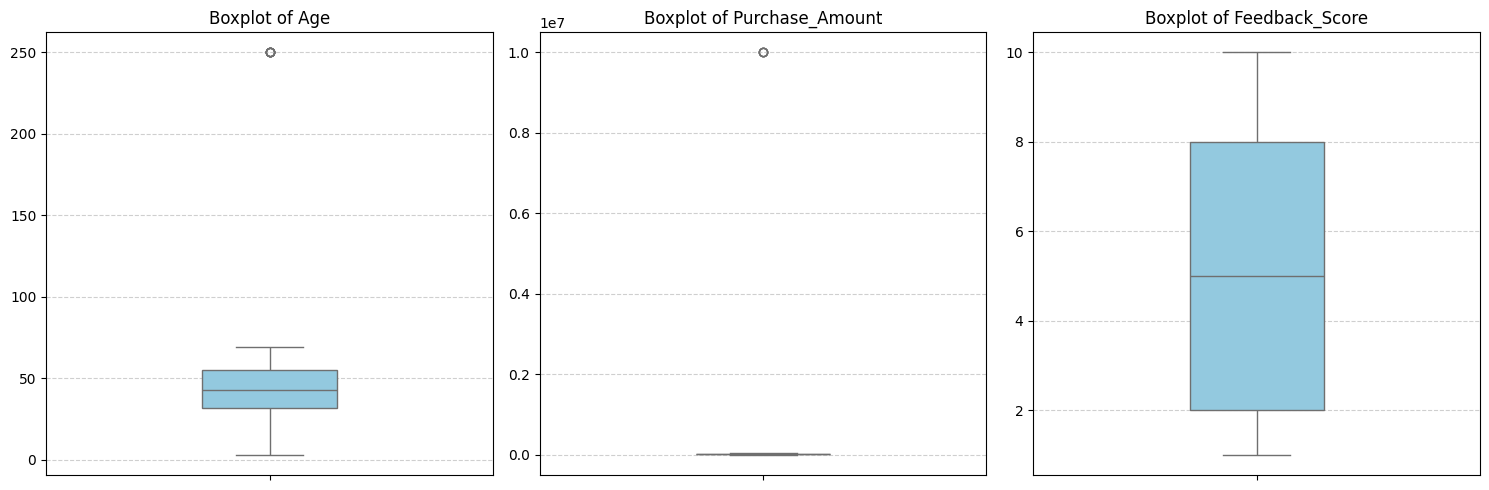

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [115]:
from scipy import stats

In [116]:
stats.zscore(df[['Age', 'Purchase_Amount']])

array([[ 0.54925759, -0.01014723],
       [ 0.48399151,  0.07152616],
       [ 1.2019184 ,  0.0126395 ],
       ...,
       [-0.5602658 , -0.02332755],
       [-1.21292662,  0.07000736],
       [ 0.74505583, -0.0486725 ]], shape=(9000, 2))

In [118]:
import numpy as np

z_score = np.abs(stats.zscore(df[['Age', 'Purchase_Amount']]))

In [122]:
df_clean = df[~(z_score >3).any(axis = 1)]

In [123]:
df_clean.shape

(8989, 12)

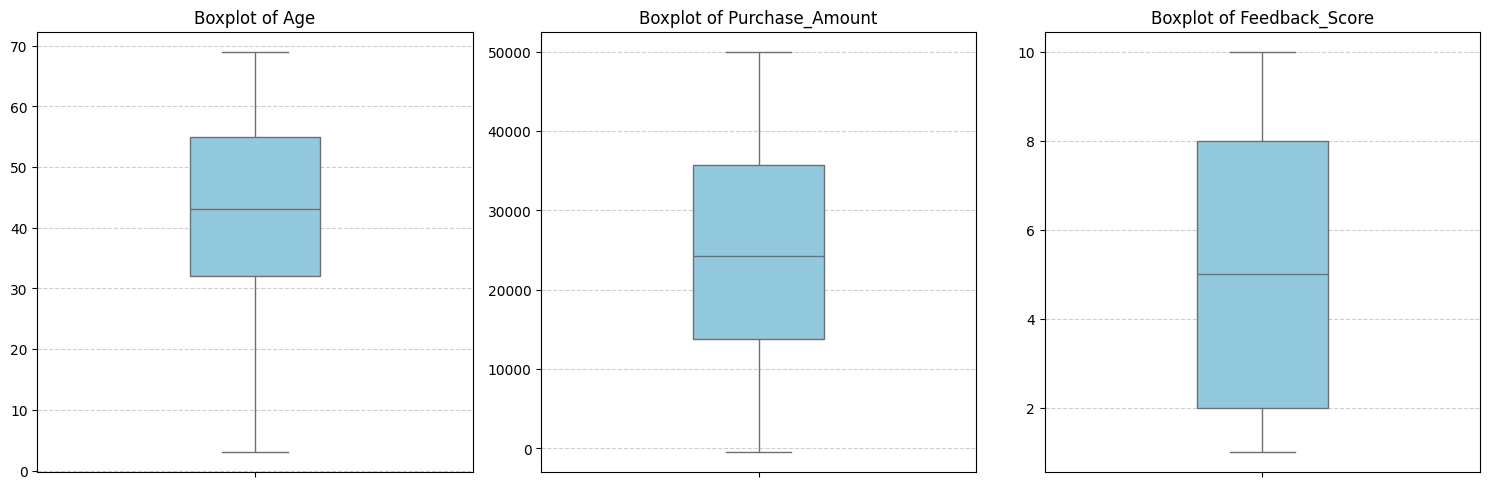

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_clean[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()